<a href="https://colab.research.google.com/github/kk910925/Data-Analysis/blob/main/0725_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd

titanic_df = sns.load_dataset('titanic')
display(titanic_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
display(titanic_df.tail())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [3]:
display(titanic_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

In [4]:
display(titanic_df.describe())

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
display(titanic_df.isnull().sum())

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
display(titanic_df.dtypes)

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [7]:
titanic_df_category = titanic_df.select_dtypes(include=['object', 'category'])
display(titanic_df_category.head())

,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no


In [8]:
cols = titanic_df_category.columns
cols

Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')

In [9]:

print("\nUnique values for object and category columns:")
for column in cols:
    print(f"\nColumn '{column}':")
    display(titanic_df[column].unique()) # 查看非數值類資料的種類有哪些?
    print()



Unique values for object and category columns:

Column 'sex':


array(['male', 'female'], dtype=object)



Column 'embarked':


array(['S', 'C', 'Q', nan], dtype=object)



Column 'class':


...

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']



Column 'embark_town':


array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)



Column 'alive':


array(['no', 'yes'], dtype=object)

In [10]:
titanic_df['sex'].value_counts()

,count
sex,
male,577
female,314


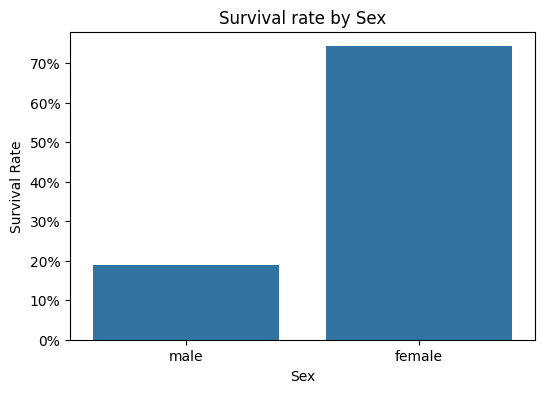

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(6, 4))
sns.barplot(
    x='sex', y='survived', data=titanic_df,
    errorbar=None
)
plt.title('Survival rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.savefig('sex_vs_survived.png')
plt.show()

/tmp/ipykernel_805/1408244725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


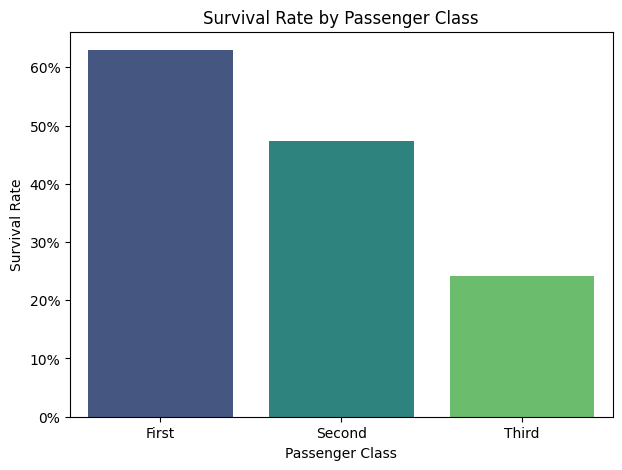

In [12]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='class', y='survived',  # 欄位名稱
    data=titanic_df,
    palette='viridis', # 顏色風格
    errorbar=None
)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

/tmp/ipykernel_805/1147804407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


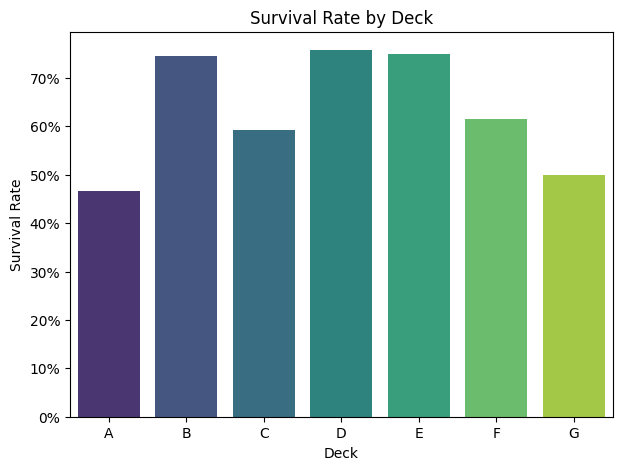

In [13]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='deck', y='survived',  # 欄位名稱
    data=titanic_df,
    palette='viridis', # 顏色風格
    errorbar=None
)
plt.title('Survival Rate by Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

/tmp/ipykernel_805/2740417297.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


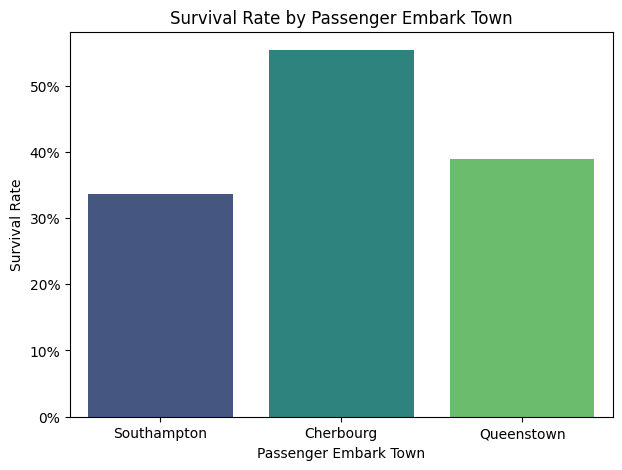

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='embark_town', y='survived',  # 欄位名稱
    data=titanic_df,
    palette='viridis', # 顏色風格
    errorbar=None
)
plt.title('Survival Rate by Passenger Embark Town')
plt.xlabel('Passenger Embark Town')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

In [15]:
first_class_df_with_deck = titanic_df[(titanic_df['pclass']==1) & (titanic_df['deck'].notna())]
first_class_df_with_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [16]:
first_class_df_with_deck['deck'].unique()

['C', 'E', 'A', 'B', 'D']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [17]:
def is_deck_a_g(deck_name):
  if deck_name=='A':
        return "Deck A"
  elif deck_name=='G':
        return "Deck G"
  else:
        return "Other Deck"

first_class_df_with_deck['deck_group'] = first_class_df_with_deck['deck'].apply(is_deck_a_g)
first_class_df_with_deck

/tmp/ipykernel_805/3751136238.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_class_df_with_deck['deck_group'] = first_class_df_with_deck['deck'].apply(is_deck_a_g)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,deck_group
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Other Deck
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Other Deck
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,Other Deck
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,Other Deck
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True,Deck A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,Other Deck
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,Other Deck
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,Other Deck
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,Other Deck


In [18]:
# # 篩選出頭等艙 (pclass == 1) 且 'deck' 欄位非空值的乘客
# first_class_df_with_deck = titanic_df[
#     (titanic_df['pclass'] == 1) & (titanic_df['deck'].notna())].copy()

# # 將甲板分為 'Deck A' 和 'Other Decks'
# first_class_df_with_deck['deck_group'] = first_class_df_with_deck['deck'].apply(lambda x: 'Deck A' if x == 'A' else 'Other Decks')

# 計算這兩組的生存率
survival_rates_first_class_by_deck_group = first_class_df_with_deck.groupby('deck_group')['survived'].mean().reset_index()

print("頭等艙乘客在 Deck A or G 與其他甲板的生存率：")
display(survival_rates_first_class_by_deck_group)

頭等艙乘客在 Deck A or G 與其他甲板的生存率：


,deck_group,survived
0,Deck A,0.466667
1,Other Deck,0.687500


In [19]:
display(titanic_df['deck'].value_counts())
display(first_class_df_with_deck['deck'].value_counts())

,count
deck,
C,59
B,47
D,33
E,32
A,15
F,13
G,4


,count
deck,
C,59
B,47
D,29
E,25
A,15
F,0
G,0


/tmp/ipykernel_805/3886642468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


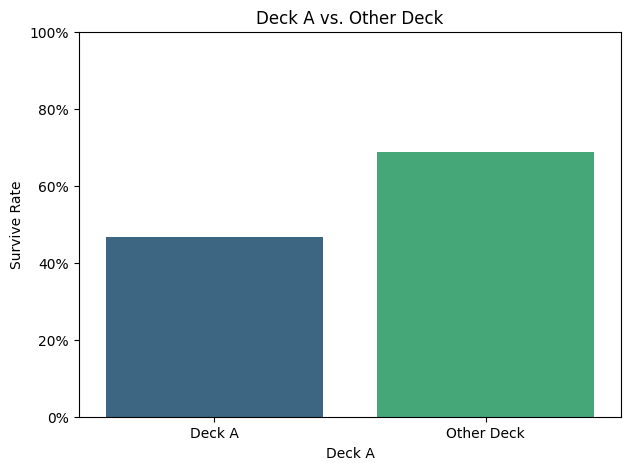

In [20]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='deck_group',
    y='survived',
    data=survival_rates_first_class_by_deck_group,
    palette='viridis',
    errorbar=None
)
plt.title('Deck A vs. Other Deck')
plt.xlabel('Deck A')
plt.ylabel('Survive Rate')
plt.ylim(0, 1) # 設定 Y 軸範圍在 0 到 1 之間，因為是生存率
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

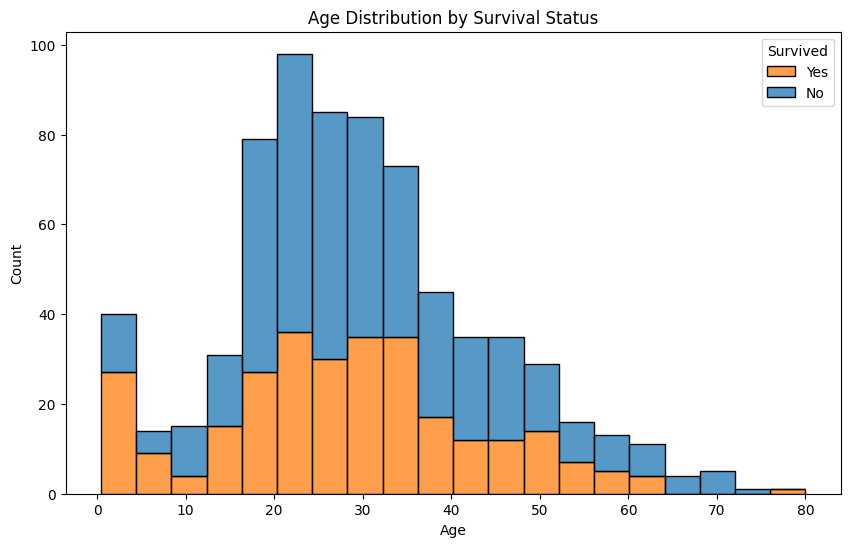

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=titanic_df,
    x='age', # x軸連續數值
    hue='survived', # y軸連續數值
    # kde=True, # 是否畫曲線
    # palette='coolwarm',
    multiple='stack' # 是否疊起來
)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Yes', 'No'])
plt.show()

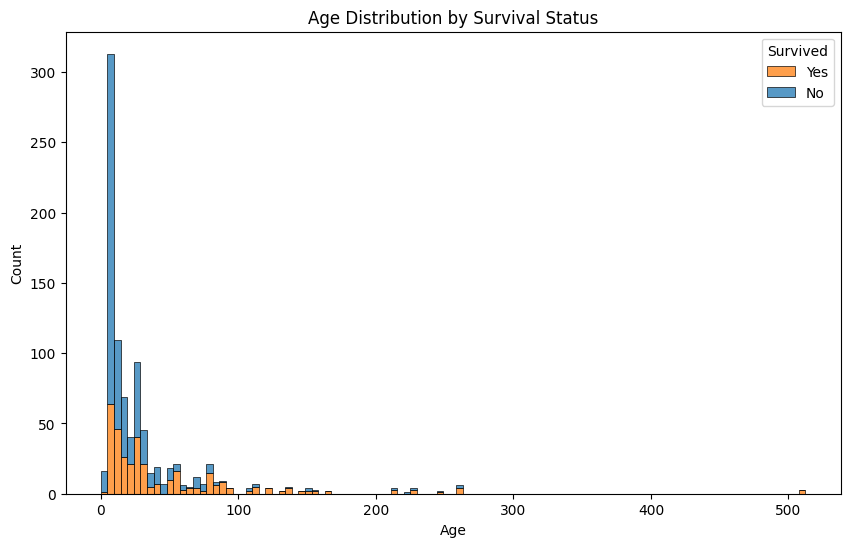

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=titanic_df,
    x='fare', # x軸連續數值
    hue='survived', # y軸連續數值
    # kde=True, # 是否畫曲線
    # palette='coolwarm',
    multiple='stack' # 是否疊起來
)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Yes', 'No'])
plt.show()

/tmp/ipykernel_805/3945110627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


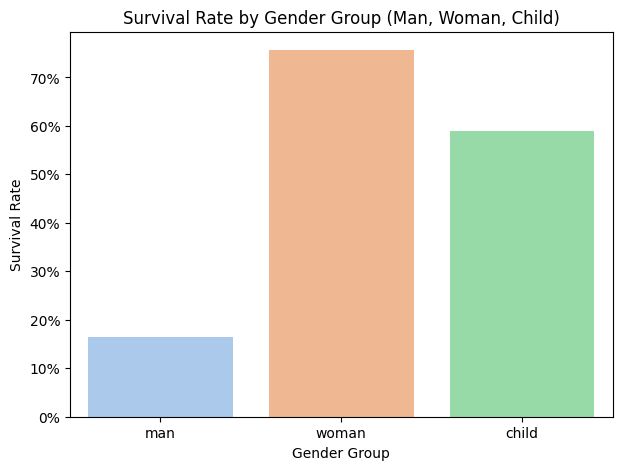

In [23]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='who', y='survived', data=titanic_df,
    palette='pastel', # 選擇一個不同的調色盤
    errorbar=None
)
plt.title('Survival Rate by Gender Group (Man, Woman, Child)')
plt.xlabel('Gender Group')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

In [24]:
titanic_df[titanic_df['age']>=65]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
456,0,1,male,65.0,0,0,26.5500,S,First,man,True,E,Southampton,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False


In [25]:
# 複製現有的 'who' 欄位作為基礎
titanic_df['who_extended'] = titanic_df['who']

# 將 65 歲及以上的乘客歸類為 'elderly'
# 注意：這裡會覆蓋掉原先是 'man' 或 'woman' 的老年人
titanic_df.loc[titanic_df['age'] >= 65, 'who_extended'] = 'elderly'

display(titanic_df['who'].value_counts())
print(titanic_df['who'].value_counts().sum())

display(titanic_df['who_extended'].value_counts())
print(titanic_df['who_extended'].value_counts().sum())

# 檢查新的 'who_extended' 欄位的唯一值，確認分類正確
print("新的 'who_extended' 分類：", titanic_df['who_extended'].unique())


,count
who,
man,537
woman,271
child,83


891


,count
who_extended,
man,526
woman,271
child,83
elderly,11


891
新的 'who_extended' 分類： ['man' 'woman' 'child' 'elderly']


/tmp/ipykernel_805/2095139477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


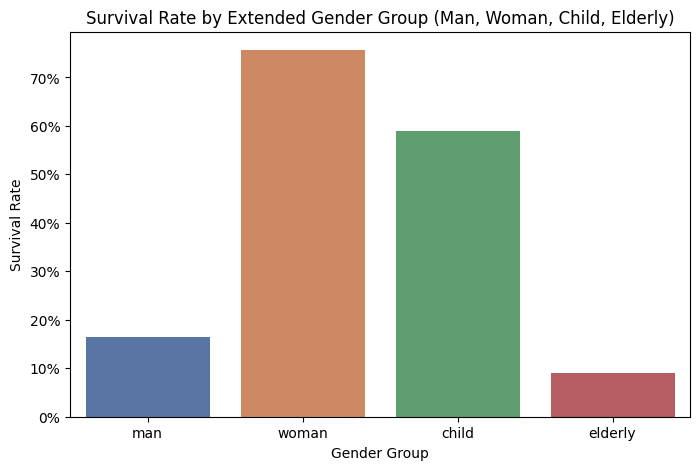

In [26]:
# 繪製不同群體 (男人、女人、小孩、老人) 的生存率
plt.figure(figsize=(8, 5))
sns.barplot(
    x='who_extended', y='survived', data=titanic_df,
    palette='deep', # 選擇一個不同的調色盤
    errorbar=None   # 不顯示誤差棒
)
plt.title('Survival Rate by Extended Gender Group (Man, Woman, Child, Elderly)')
plt.xlabel('Gender Group')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
import numpy as np

# 複製 DataFrame 以免影響原始數據
df_ml = titanic_df.copy()

<Figure size 1000x600 with 0 Axes>

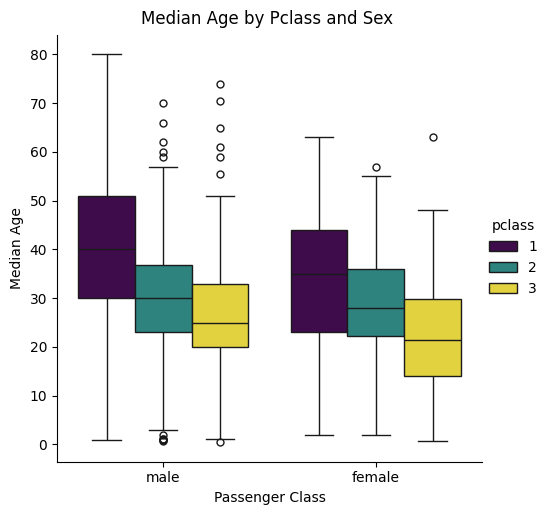

In [28]:
# 繪製根據艙等和性別劃分的年齡中位數
plt.figure(figsize=(10, 6))
sns.catplot(
    x='sex',
    y='age',
    hue='pclass',
    data=df_ml,
    kind='box',
    palette='viridis'
)
plt.suptitle('Median Age by Pclass and Sex', y=1.02) # 調整總標題位置
plt.xlabel('Passenger Class')
plt.ylabel('Median Age')
plt.show()

In [31]:
# 傳統作法: 用分組中位數填補
for g_name, g_deta in df_ml.groupby(['sex','pclass']):
  group_age_median = g_deta['age'].median()
  g_deta['age'].fillna(group_age_median, inplace=True)
  # 須將針對view的修改，實際的更動到原df
  df_ml.loc[g_deta.index, 'age'] = g_deta['age']

/tmp/ipykernel_805/25169569.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  g_deta['age'].fillna(group_age_median, inplace=True)
/tmp/ipykernel_805/25169569.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [32]:

# 或使用.transform廣播回原df
median_age_by_group = df_ml.groupby(['sex', 'pclass'])['age'].transform('median')
# 使用計算出的中位數來填補 'age' 欄位的缺失值
df_ml['age'].fillna(median_age_by_group, inplace=True)

print("'age' 缺失值已根據 'sex' 和 'pclass' 的分組中位數填補。")
print("確認 'age' 欄位是否還有缺失值：", df_ml['age'].isnull().sum())

'age' 缺失值已根據 'sex' 和 'pclass' 的分組中位數填補。
確認 'age' 欄位是否還有缺失值： 0


/tmp/ipykernel_805/1795351355.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['age'].fillna(median_age_by_group, inplace=True)


In [33]:
# 他缺失的並沒有很多筆
mode_embarked = df_ml['embarked'].mode()[0]
df_ml['embarked'].fillna(mode_embarked, inplace=True)
print(f"'embarked' 缺失值已使用眾數 '{mode_embarked}' 填補。")

'embarked' 缺失值已使用眾數 'S' 填補。


/tmp/ipykernel_805/3792656700.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['embarked'].fillna(mode_embarked, inplace=True)


In [34]:
df_ml.drop('embark_town', axis=1, inplace=True)
print("'embark_town' 欄位已丟棄。")

'embark_town' 欄位已丟棄。


In [35]:
df_ml['has_deck'] = df_ml['deck'].notna().astype(int)
df_ml.drop('deck', axis=1, inplace=True)
print("'deck' 欄位已轉換為 'has_deck' 特徵並丟棄原始欄位。")


'deck' 欄位已轉換為 'has_deck' 特徵並丟棄原始欄位。


In [36]:
print("\n處理缺失值後，各欄位的缺失值數量：")
display(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])


處理缺失值後，各欄位的缺失值數量：


,0


In [38]:
# --- 類別特徵編碼與特徵選擇 ---

# 定義用於模型的特徵 (X) 和目標變數 (y)
# 'survived' 是目標變數
# 'pclass', 'sibsp', 'parch', 'fare', 'age' 是數值特徵
# 'sex', 'embarked', 'class', 'who_extended' 是需要 One-Hot 編碼的類別特徵
# 'alone', 'adult_male', 'has_deck' 是布林/二元特徵

features = [
    #'pclass',
    'age', 'sibsp', 'parch', 'fare',
    'sex', 'embarked', 'class', 'who_extended',
    'alone'
    #, 'adult_male', 'has_deck'
]

# 選取特徵和目標變數
X = df_ml[features]
y = df_ml['survived']


In [39]:
# 識別類別型欄位
categorical_features = ['sex', 'embarked', 'class', 'who_extended']

# 使用 OneHotEncoder 進行編碼
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_features]) # 針對"類別行"處理

# 獲取新的特徵名稱
encoded_feature_names = encoder.get_feature_names_out(categorical_features) # 把每一行名稱列出來

# 將編碼後的特徵轉換為 DataFrame
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names, index=X.index)
display(X_encoded_df.head())

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_extended_child,who_extended_elderly,who_extended_man,who_extended_woman
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [40]:

# 將數值特徵和編碼後的類別特徵合併
X_numerical = X.drop(columns=categorical_features) # 丟掉 'sex', 'embarked', 'class', 'who_extended'
X_processed = pd.concat([X_numerical, X_encoded_df], axis=1) # 把剩下的欄位 + 新的encoded欄位

print("\n資料預處理完成。現在的特徵集 (X_processed) 的前5行：")
display(X_processed.head())
print(f"\n處理後的特徵維度: {X_processed.shape}")



資料預處理完成。現在的特徵集 (X_processed) 的前5行：


,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_extended_child,who_extended_elderly,who_extended_man,who_extended_woman
0,22.0,1,0,7.2500,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,38.0,1,0,71.2833,False,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,26.0,0,0,7.9250,True,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,35.0,1,0,53.1000,False,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,35.0,0,0,8.0500,True,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0



處理後的特徵維度: (891, 17)


In [41]:
# 將資料切分為訓練集和測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集特徵形狀: {X_train.shape}")
print(f"測試集特徵形狀: {X_test.shape}")
print(f"訓練集目標形狀: {y_train.shape}")
print(f"測試集目標形狀: {y_test.shape}")

print("\n資料已成功切分為訓練集和測試集。接下來可以訓練 Random Forest 模型了！")


訓練集特徵形狀: (712, 17)
測試集特徵形狀: (179, 17)
訓練集目標形狀: (712,)
測試集目標形狀: (179,)

資料已成功切分為訓練集和測試集。接下來可以訓練 Random Forest 模型了！


In [42]:
# 初始化 Random Forest 分類器
# n_estimators: 樹的數量，可以調整來取的最佳結果
# random_state: 隨機種子，確保結果可重現
rf_model = RandomForestClassifier(n_estimators=2000, random_state=42)

# 訓練模型
rf_model.fit(X_train, y_train)

print("Random Forest 模型訓練完成！")


Random Forest 模型訓練完成！


In [43]:
# 在測試集上進行預測
y_pred = rf_model.predict(X_test)

# 評估模型性能
print("模型準確度 (Accuracy):", accuracy_score(y_test, y_pred))
print("\n分類報告 (Classification Report):\n", classification_report(y_test, y_pred))


模型準確度 (Accuracy): 0.8212290502793296

分類報告 (Classification Report):
               precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

